In [1]:
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from transformers.pipelines import pipeline
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic.vectorizers import OnlineCountVectorizer

C:\Python\envs\LYK\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open(r"C:\Users\Lyk\Desktop\黑神话悟空-数据\英文评论\6.0-Final\ENG-纯文本-3.0.txt", 'r', encoding='utf-8') as file:
  docs = file.readlines()
print('条数: ', len(docs))
print('预览第一条: ', docs[0])

vectorizer_model = None

条数:  29498
预览第一条:  Best game of all time



In [4]:
stopwords_path = r"C:\Users\Lyk\Desktop\黑神话ldabertopic\词典\英文停用词.txt"
with open(stopwords_path, "r", encoding="utf-8") as f:
    custom_stopwords = [line.strip() for line in f if line.strip()]

print(f"加载停词数量: {len(custom_stopwords)}")
print(custom_stopwords[:10])  # 示例输出前10个停词

加载停词数量: 569
['a', 'aa', 'aaa', 'ah', 'aah', 'ahh', 'ahhh', 'able', 'about', 'above']


In [27]:
embedding_model = pipeline("feature-extraction", model= "sentence-transformers/paraphrase-multilingual-mpnet-base-v2") 
embeddings = np.load(r"C:\Users\Lyk\Desktop\黑神话悟空-数据\英文评论\词向量\emb(mpnet-base-v2-ENG-3.0).npy") 
print(embeddings.shape)


umap_model = UMAP(
  n_neighbors=15,
  n_components=5,
  min_dist=0.0,
  metric='cosine',
  random_state=42 
)


hdbscan_model = HDBSCAN(
  min_cluster_size= 35,
  min_samples = 35,
  metric='euclidean', 
  cluster_selection_method='eom',
  prediction_data=False
)


vectorizer_model = OnlineCountVectorizer(min_df=10, ngram_range=(1, 2), stop_words = custom_stopwords)

ctfidf_model = ClassTfidfTransformer()

Device set to use cuda:0


(29498, 768)


In [28]:
from bertopic.representation import MaximalMarginalRelevance
representation_model = MaximalMarginalRelevance(diversity=0.3)

topic_model = BERTopic(
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  vectorizer_model=vectorizer_model,
  ctfidf_model=ctfidf_model,
  top_n_words=30,
  calculate_probabilities= False,
  representation_model=representation_model
)

topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,9245,-1_good_bosses_combat_fun,"[good, bosses, combat, fun, chapter, graphics,...",[Audio/Sound Effects = 10/10 It couldn't feel ...
1,0,3061,0_fights_dodge_boss fights_hit,"[fights, dodge, boss fights, hit, combat, enem...",[Changing fighting stance is only way to use s...
2,1,2812,1_wukong_myth wukong_sun wukong_story,"[wukong, myth wukong, sun wukong, story, journ...","[Black Myth: Wukong is GOTY!\n, She black on m..."
3,2,1417,2_chinese_chinese mythology_china_journey west,"[chinese, chinese mythology, china, journey we...","[Yes, i like Chinese food, it is yum.\n, MONKE..."
4,3,1346,3_souls_souls game_god war_souls games,"[souls, souls game, god war, souls games, dark...","[If you like God of War, and if you enjoy Dark..."
5,4,1202,4_monkey_monkey king_monkey game_play monkey,"[monkey, monkey king, monkey game, play monkey...","[Monkey. What else do you need to know?\n, ""Mm..."
6,5,858,5_invisible walls_invisible wall_explore_paths,"[invisible walls, invisible wall, explore, pat...",[As you try to explore you will probably facep...
7,6,749,6_fps_pc_frame_fix,"[fps, pc, frame, fix, rtx, ram, gpu, stutterin...",[Runs fine on my PC but I am running a 4090/hi...
8,7,675,7_great combat_game combat_combat system_comba...,"[great combat, game combat, combat system, com...",[Amazing game 9.5/10 Great combat system Great...
9,8,663,8_goty_buy_worth_good,"[goty, buy, worth, good, 10 10, love, fun hard...","[Also it should be GOTY prolly.\n, It fulfills..."


In [30]:
new_topics = topic_model.reduce_outliers(
  docs,
  topics,
  strategy="embeddings",
  embeddings=embeddings, 
  threshold=0.6
)

topic_model.update_topics(docs, topics=new_topics, vectorizer_model=vectorizer_model) 
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,6956,-1_game_boss_bosses_10,"[game, boss, bosses, 10, good, chapter, story,...",[Audio/Sound Effects = 10/10 It couldn't feel ...
1,0,3071,0_boss_bosses_attack_attacks,"[boss, bosses, attack, attacks, fight, fights,...",[Changing fighting stance is only way to use s...
2,1,2814,1_wukong_myth_black myth_black,"[wukong, myth, black myth, black, myth wukong,...","[Black Myth: Wukong is GOTY!\n, She black on m..."
3,2,1424,2_chinese_mythology_chinese mythology_china,"[chinese, mythology, chinese mythology, china,...","[Yes, i like Chinese food, it is yum.\n, MONKE..."
4,3,1350,3_souls_souls game_god war_war,"[souls, souls game, god war, war, god, souls g...","[If you like God of War, and if you enjoy Dark..."
5,4,1205,4_monkey_stick_monkey king_king,"[monkey, stick, monkey king, king, monkey game...","[Monkey. What else do you need to know?\n, ""Mm..."
6,5,858,5_invisible_walls_invisible walls_map,"[invisible, walls, invisible walls, map, wall,...",[As you try to explore you will probably facep...
7,6,749,6_crash_fps_settings_performance,"[crash, fps, settings, performance, pc, frame,...",[Runs fine on my PC but I am running a 4090/hi...
8,7,697,7_combat_great_story_graphics,"[combat, great, story, graphics, fun, amazing,...",[Amazing game 9.5/10 Great combat system Great...
9,8,663,8_goty_buy_fun_10,"[goty, buy, fun, 10, worth, hard, good, recomm...","[Also it should be GOTY prolly.\n, It fulfills..."


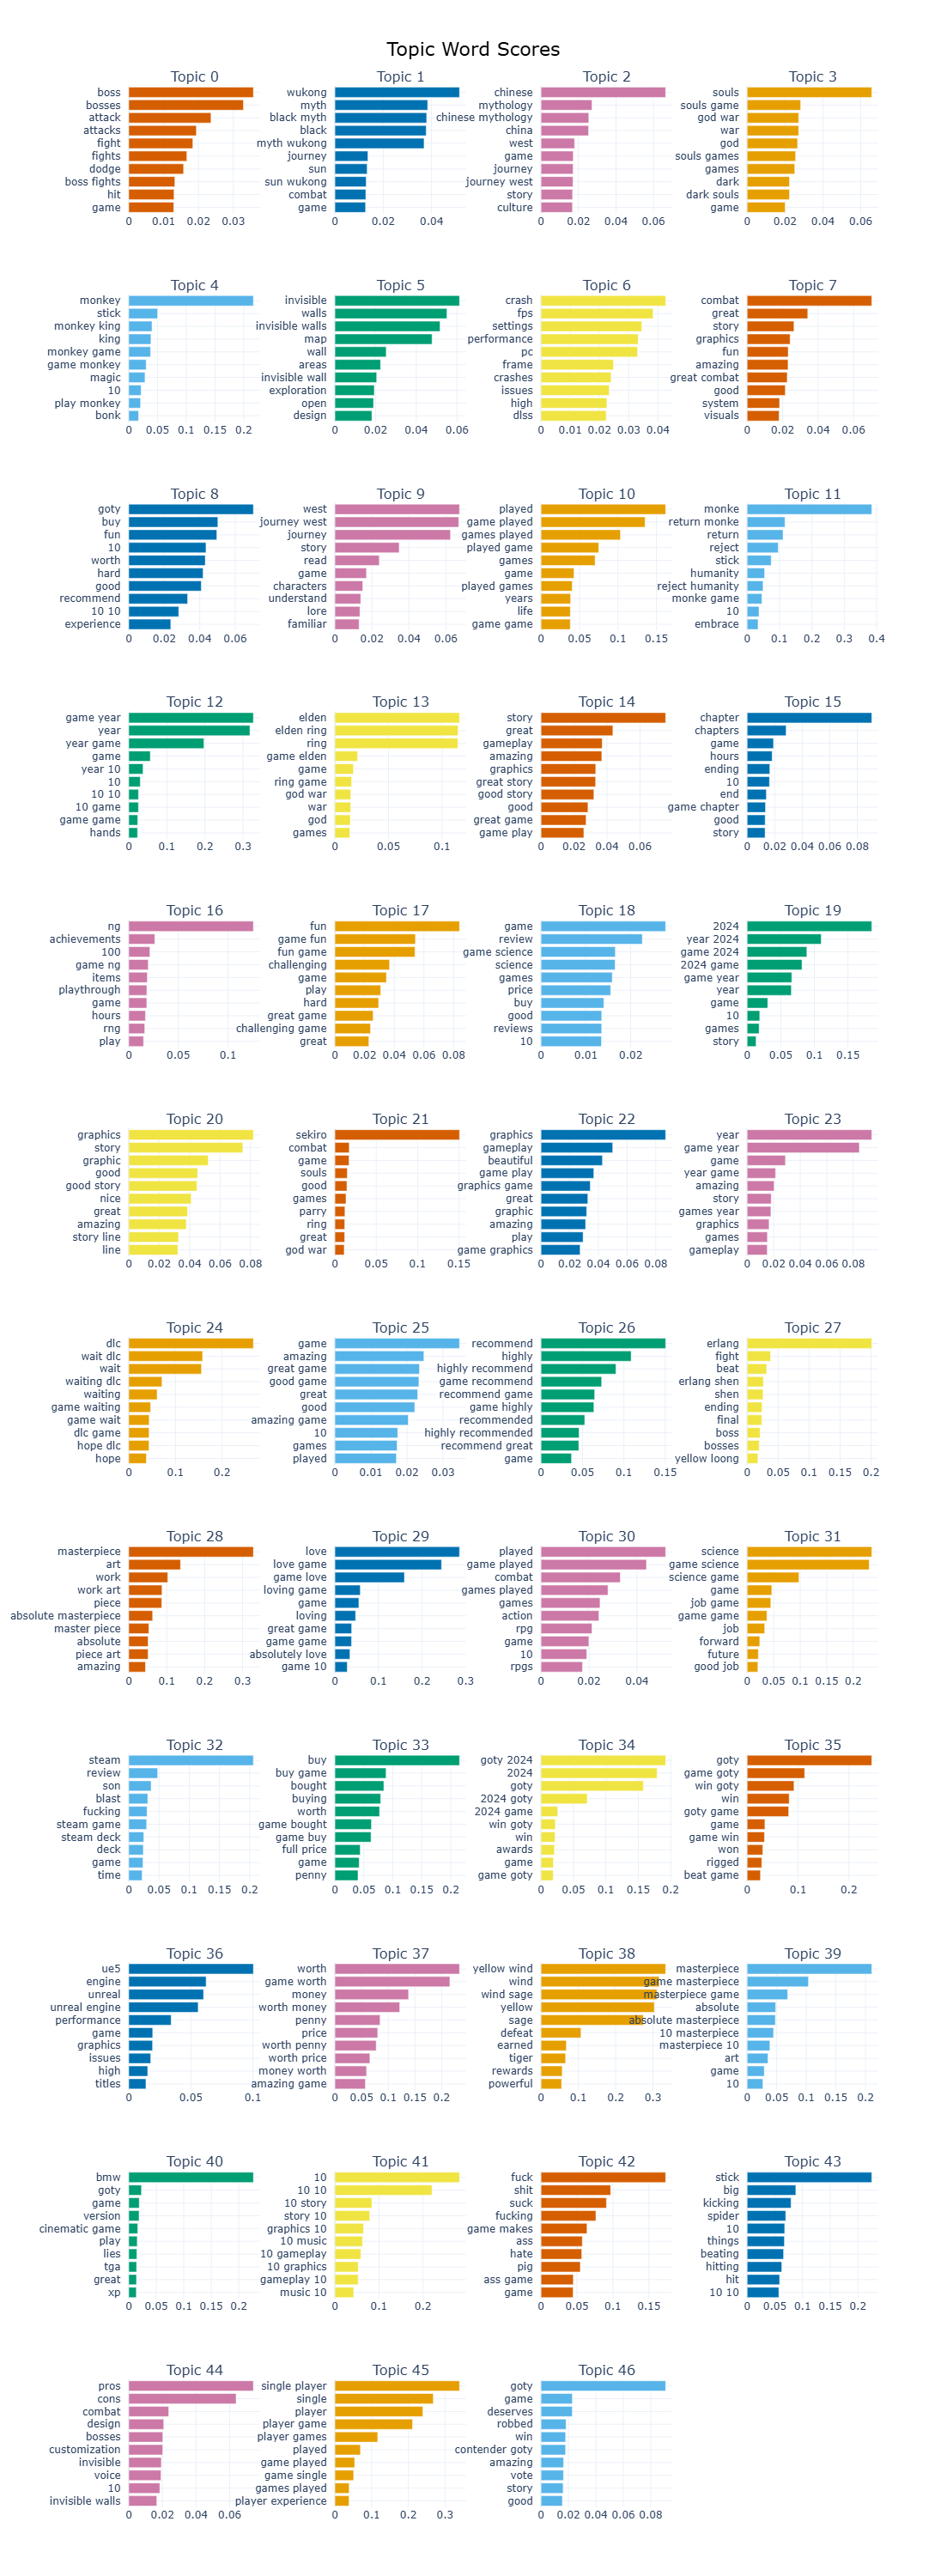

In [34]:
fig = topic_model.visualize_barchart(top_n_topics= 47, n_words = 10)
fig.show()
fig.write_html(r"C:\Users\Lyk\Desktop\黑神话悟空-数据\英文评论\主题词图-4.0.html")

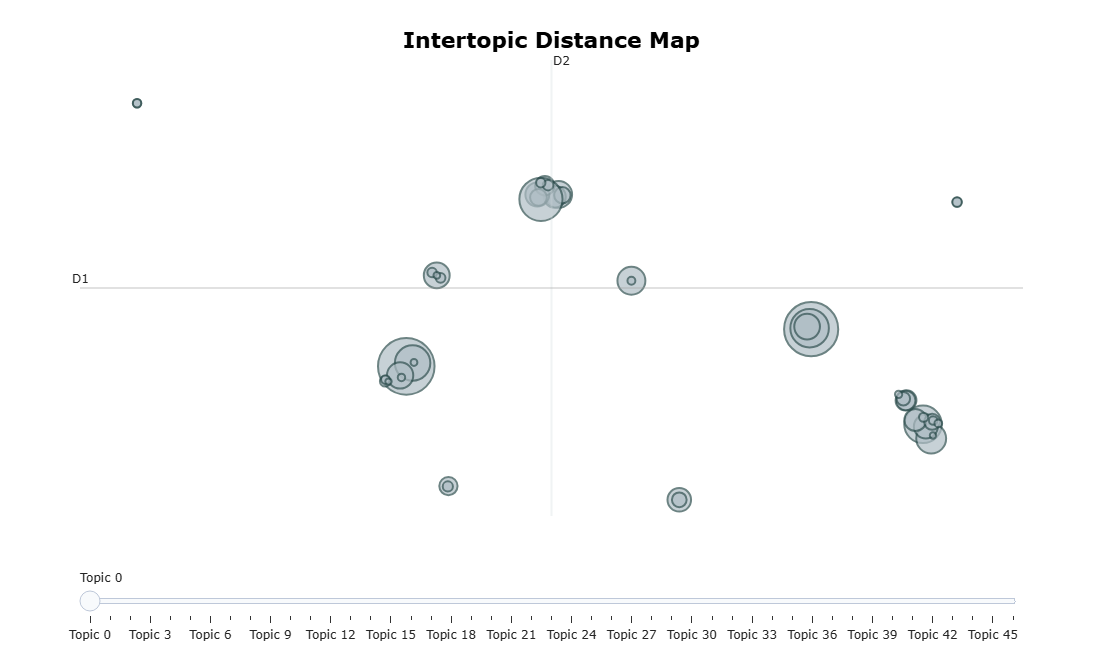

In [35]:
fig = topic_model.visualize_topics()
fig.show()
fig.write_html(r"C:\Users\Lyk\Desktop\黑神话悟空-数据\英文评论\气泡图-4.0.html")

100%|█████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 125.09it/s]


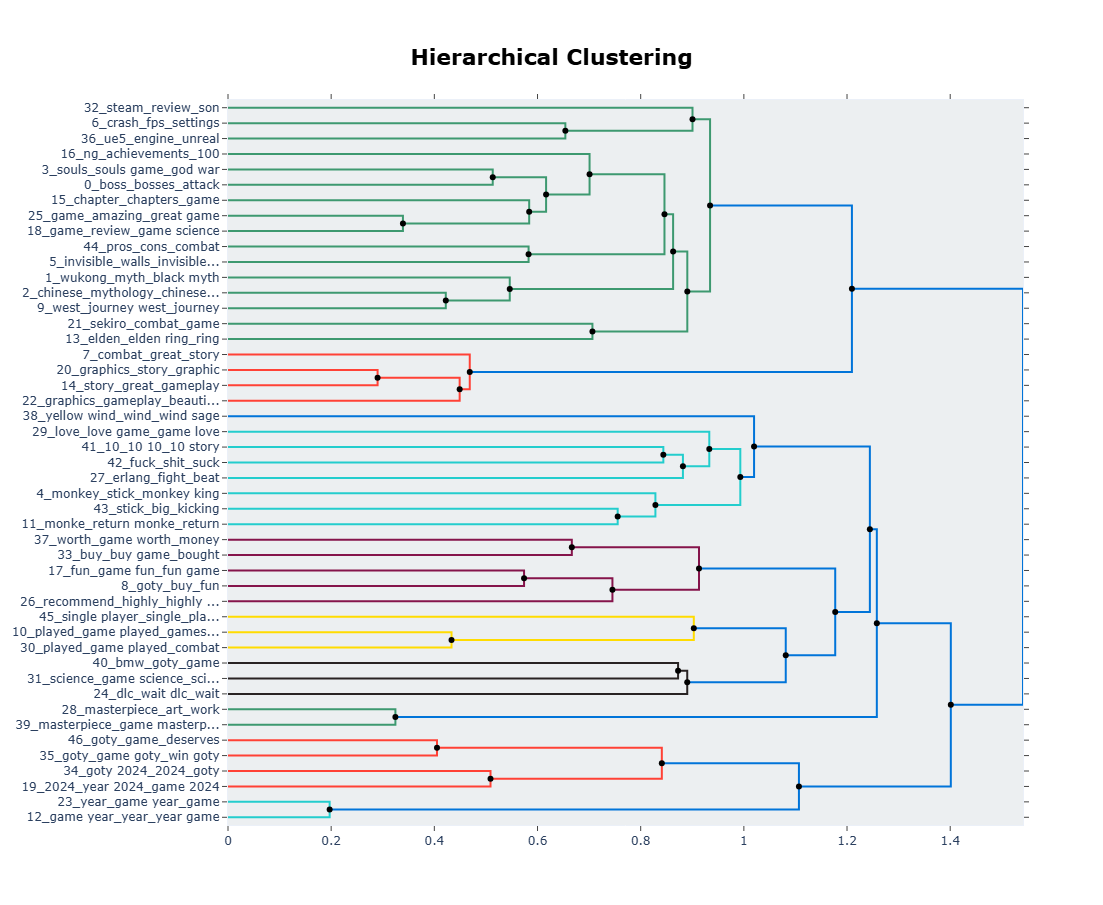

In [36]:
hierarchical_topics = topic_model.hierarchical_topics(docs)
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

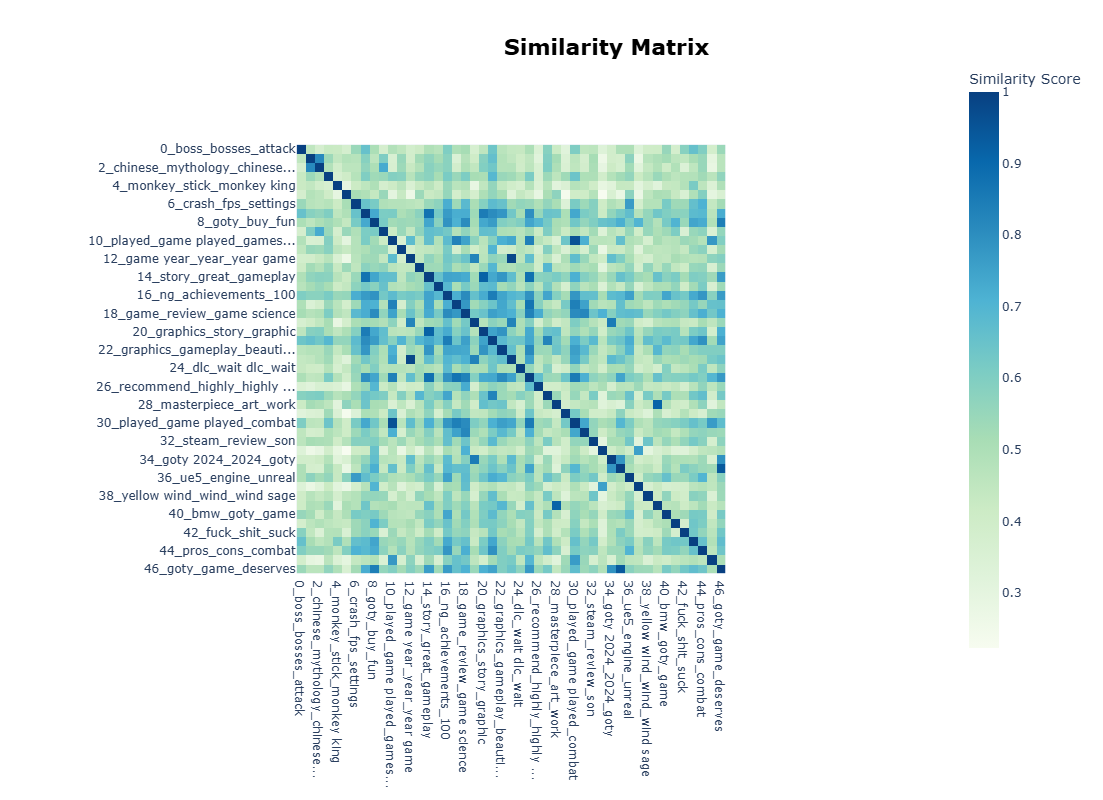

In [37]:
pic = topic_model.visualize_heatmap()
pic.write_html(r"C:\Users\Lyk\Desktop\黑神话悟空-数据\英文评论\主题相似度图-4.0.html")
pic.show()